# Baseline Recognition

This notebook establishes a **baseline** for cattle identification using a pretrained ResNet50 model, with **no fine-tuning**. The goal is to measure how well generic ImageNet features can distinguish individual cows by their muzzle patterns, before any specialized training.

## Imports

Load all required libraries for **deep learning, image processing, similarity measurement,** and **visualization**.

1. **os:** File system navigation (listing folders, building paths)
2. **torch:** PyTorch deep learning framework
3. **random:** For randomly sampling cows/images during evaluation
4. **numpy:** Numerical operations (mean, min, max on similarity scores)
5. **PIL**
    - **_Image:_** Loading image files from disk
6. **torchvision**
    - **_models:_** Pretrained models (ResNet50)
    - **_transforms:_** Image preprocessing pipelines
7. **sklearn.metrics.pairwise**
    - **_cosine_similarity:_** Measures how "close" two embedding vectors are (0=different, 1=identical)
8. **matplotlib.pyplot:** Plotting histograms and displaying images

In [1]:
import os
import torch
import random
import numpy as np
from PIL import Image
from torchvision import models, transforms
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

## Environment Check

Verify that PyTorch is installed correctly and a GPU is available. GPU acceleration is critical for inference speed, CPU-only runs would be ~10–100× slower.

In [2]:
print("Torch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
CUDA Available: True
CUDA Version: 12.8
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## Device Selection

Hard-code the compute device to **CUDA (GPU)**.

> **Note:** This will crash if no GPU is present. A safer pattern is `torch.device("cuda" if torch.cuda.is_available() else "cpu")`, which is used in the later notebooks.

In [3]:
device = torch.device("cuda")

## Load Pretrained ResNet50

Load ResNet50 pretrained on **ImageNet** (1.2M images, 1000 classes) and convert it into a **feature extractor**.

- `weights=ResNet50_Weights.DEFAULT` - loads the best available pretrained weights.
- `model.fc = Identity()` - removes the final 1000-class classification head; the model now outputs a raw **2048-dimensional embedding** instead of class probabilities.
- `.eval()` - disables dropout and freezes batch norm statistics for stable inference.

In [4]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

model.fc = torch.nn.Identity()

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Image Preprocessing Pipeline

Define the transformation applied to every image before it enters the model.

- `Resize((224, 224))` - ResNet50 requires exactly 224×224 pixel input.
- `ToTensor()` - converts a PIL Image (H×W×C, uint8 0–255) to a PyTorch tensor (C×H×W, float32 0.0–1.0).

> **Limitation:** A production pipeline would also add `Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])` to match ImageNet's statistics. Omitting it is a known baseline limitation.

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## Define Sample Image Paths

Point to three specific images for a quick sanity check:

- `img1_path` and `img2_path`: two different photos of **the same cow** (`cattle_0100`).
- `img3_path`: a photo of a **different cow** (`cattle_0200`).

If the model works correctly, `img1` and `img2` should produce similar embeddings, while `img3` should be dissimilar.

In [6]:
img1_path = "../data/raw/BeefCattle_Muzzle/cattle_0100/cattle_0100_DSCF3856.jpg"
img2_path = "../data/raw/BeefCattle_Muzzle/cattle_0100/cattle_0100_DSCF3858.jpg"
img3_path = "../data/raw/BeefCattle_Muzzle/cattle_0200/cattle_0200_DJI_0115.jpg"

## Display Image 1 (Cow 0100, Photo A)

Open and display the first image of cow 0100. `plt.axis("off")` hides axis tick marks for a cleaner view.

(np.float64(-0.5), np.float64(2087.5), np.float64(1767.5), np.float64(-0.5))

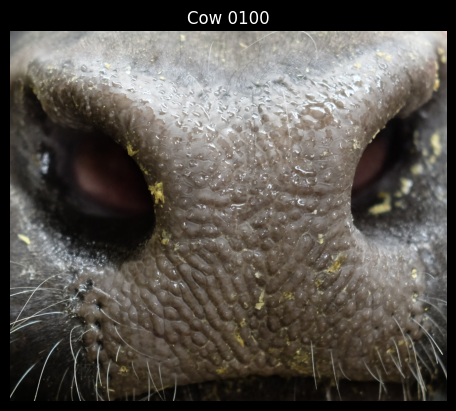

In [7]:
img1 = Image.open(img1_path)
plt.imshow(img1)
plt.title("Cow 0100")
plt.axis("off")

## Display Image 2 (Cow 0100, Photo B)

Display the second photo of the same cow (0100). This will be compared against Photo A to measure same-cow similarity.

(np.float64(-0.5), np.float64(2943.5), np.float64(2351.5), np.float64(-0.5))

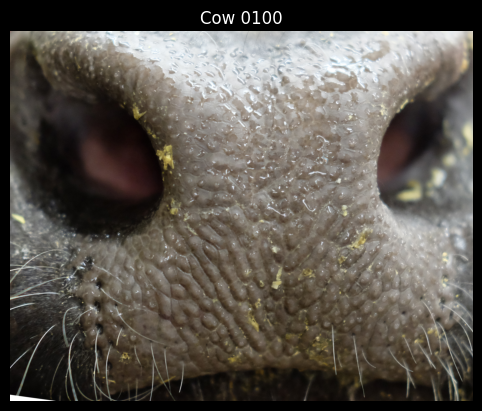

In [8]:
img2 = Image.open(img2_path)
plt.imshow(img2)
plt.title("Cow 0100")
plt.axis("off")

## Display Image 3 (Cow 0200)

Display a photo of a completely different cow (0200). Used as the negative example in the initial similarity test.

(np.float64(-0.5), np.float64(2495.5), np.float64(1471.5), np.float64(-0.5))

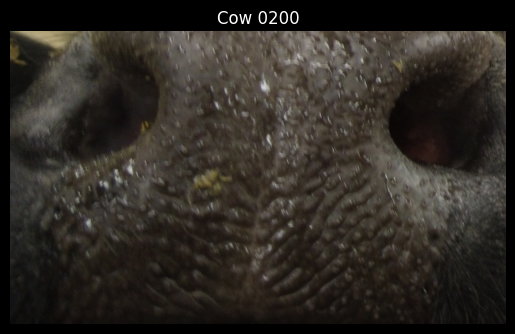

In [9]:
img3 = Image.open(img3_path)
plt.imshow(img3)
plt.title("Cow 0200")
plt.axis("off")

## `get_embedding()` Function

Define the core function that converts an image file into a **2048-dimensional feature vector**.

**Step-by-step:**
1. Open the image and force 3-channel RGB (handles grayscale or RGBA inputs).
2. Apply the preprocessing transform: tensor of shape `[3, 224, 224]`.
3. Add a batch dimension with `.unsqueeze(0)`: shape `[1, 3, 224, 224]` (models expect batches).
4. Run the forward pass inside `torch.no_grad()` to skip gradient tracking (saves memory).
5. Move the result to CPU and convert to NumPy (required by sklearn's `cosine_similarity`).

In [10]:
def get_embedding(image_path):
    image = Image.open(image_path).convert("RGB")

    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model(image)

    return embedding.cpu().numpy()

## Compute Embeddings for Three Sample Images

Run `get_embedding()` on each of the three sample images. Each result is a NumPy array of shape `[1, 2048]`.

In [11]:
emb1 = get_embedding(img1_path)
emb2 = get_embedding(img2_path)
emb3 = get_embedding(img3_path)

In [12]:
emb1

array([[0.13413335, 0.4244956 , 0.1769937 , ..., 0.00183042, 0.21244635,
        1.206874  ]], shape=(1, 2048), dtype=float32)

## Sanity Check: Same vs. Different Cow Similarity

Compute **cosine similarity** between the three embeddings to verify the model's baseline discriminative ability.

- **Cosine similarity** measures the angle between two vectors: `1.0` = identical direction, `0.0` = orthogonal, `-1.0` = opposite.
- `[0][0]` extracts the single scalar from the 2D result matrix returned by sklearn.
- Ideally: `same_similarity` >> `different_similarity`.

In [13]:
same_similarity = cosine_similarity(emb1, emb2)[0][0]

different_similarity = cosine_similarity(emb1, emb3)[0][0]

print("Same Cow Similarity:", same_similarity)
print("Different Cow Similarity:", different_similarity)

Same Cow Similarity: 0.8550497
Different Cow Similarity: 0.70410955


## Scan Dataset into a Dictionary

Walk the dataset directory and build a dictionary mapping each cow's ID to its list of image paths.

```
cattle_data = {
  "cattle_0100": ["path/to/img1.jpg", "path/to/img2.jpg", ...],
  "cattle_0200": [...],
  ...
}
```

- Only cows with **at least 2 images** are included, pairs are required for same-cow similarity testing.
- `os.path.isdir()` skips any stray non-folder files at the root level.

In [14]:
DATASET_PATH = "../data/raw/BeefCattle_Muzzle"

cattle_data = {}

for cattle_id in os.listdir(DATASET_PATH):
    cattle_folder = os.path.join(DATASET_PATH, cattle_id)

    if os.path.isdir(cattle_folder):
        image_paths = []

        for image_name in os.listdir(cattle_folder):
            image_path = os.path.join(cattle_folder, image_name)

            image_paths.append(image_path)

        if len(image_paths) >= 2:
            cattle_data[cattle_id] = image_paths

print("Total cattle:", len(cattle_data))

Total cattle: 268


## Collect 100 Same-Cow Similarity Scores

Measure how similar the model thinks two photos of the **same cow** are, across 100 random pairs.

- `random.choice()` picks a cow; `random.sample(..., 2)` picks 2 distinct images **without replacement**.
- Results are stored in `same_similarities` for statistical analysis and plotting.
- 100 samples provides a reliable distribution without excessive compute time.

In [15]:
same_similarities = []

cattle_ids = list(cattle_data.keys())

for _ in range(100):

    # Select random cow
    cattle_id = random.choice(cattle_ids)

    images = cattle_data[cattle_id]

    # Select 2 different images from same cow
    img1_path, img2_path = random.sample(images, 2)

    # Generate embeddings
    emb1 = get_embedding(img1_path)
    emb2 = get_embedding(img2_path)

    # Compute similarity
    sim = cosine_similarity(emb1, emb2)[0][0]

    same_similarities.append(sim)

print("Collected same-cow similarities:", len(same_similarities))

Collected same-cow similarities: 100


# Collect 100 Different-Cow Similarity Scores

Measure how similar the model thinks photos of **two different cows** are, across 100 random pairs.

- `random.sample(cattle_ids, 2)` selects 2 distinct cow IDs without replacement, guaranteeing they differ.
- These scores form the negative distribution; ideally much lower than the same-cow scores.

In [16]:
different_similarities = []

for _ in range(100):

    # Select 2 different cows
    cattle_id1, cattle_id2 = random.sample(cattle_ids, 2)

    img1_path = random.choice(cattle_data[cattle_id1])
    img2_path = random.choice(cattle_data[cattle_id2])

    # Generate embeddings
    emb1 = get_embedding(img1_path)
    emb2 = get_embedding(img2_path)

    # Compute similarity
    sim = cosine_similarity(emb1, emb2)[0][0]

    different_similarities.append(sim)

print("Collected different-cow similarities:", len(different_similarities))

Collected different-cow similarities: 100


## Print Summary Statistics

Print the mean, min, and max of each distribution.

**What to look for:**
- A large gap between the two **means** the model can separate cow identities.
- A small gap or overlapping ranges **means** poor baseline discrimination; training is needed.

This baseline result motivates the Siamese training in the next notebook.

### Same Cow

In [17]:
print("Mean:", np.mean(same_similarities))
print("Min :", np.min(same_similarities))
print("Max :", np.max(same_similarities))

Mean: 0.856808
Min : 0.43585542
Max : 0.97353923


### Different Cow

In [18]:
print("Mean:", np.mean(different_similarities))
print("Min :", np.min(different_similarities))
print("Max :", np.max(different_similarities))

Mean: 0.5298519
Min : 0.16582283
Max : 0.77043164


## Plot Similarity Distributions

Visualize both distributions as overlapping histograms.

- `alpha=0.6` makes both bars semi-transparent so neither hides the other.
- `bins=20` controls histogram resolution.

**Ideal result:** Two clearly separated, non-overlapping peaks, one for same-cow pairs (high similarity) and one for different-cow pairs (low similarity). Significant overlap means the baseline struggles and fine-tuning with Triplet Loss is necessary.

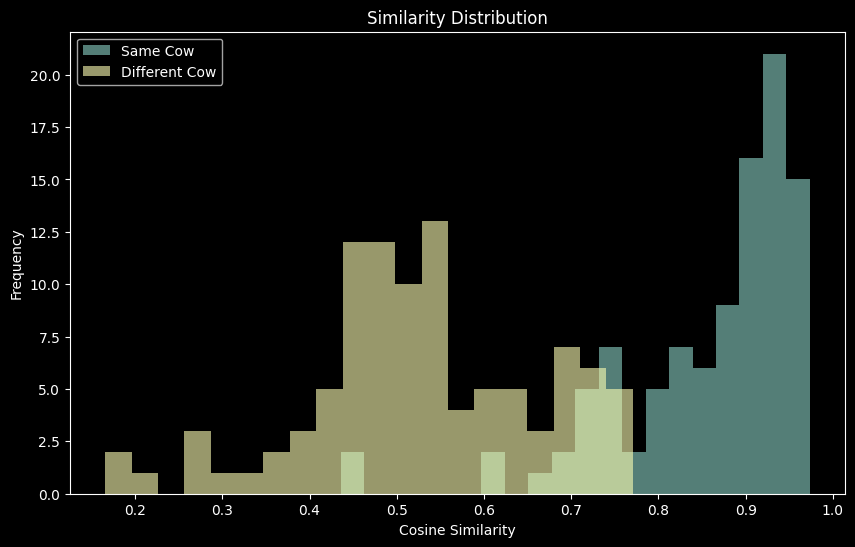

In [19]:
plt.figure(figsize=(10, 6))

plt.hist(
    same_similarities,
    bins=20,
    alpha=0.6,
    label="Same Cow"
)

plt.hist(
    different_similarities,
    bins=20,
    alpha=0.6,
    label="Different Cow"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.title("Similarity Distribution")

plt.legend()

plt.show()